# AerisPlane — Getting Started

Basic examples of defining aircraft geometry and inspecting properties.

In [1]:
import aerisplane as ap
import numpy as np

## 1. Define an Airfoil

AerisPlane can generate NACA 4-digit airfoils or load from `.dat` files.

In [2]:
# Create a NACA 2412 airfoil (2% camber at 40% chord, 12% thickness)
airfoil = ap.Airfoil.from_naca("2412")

print(f"Name:          {airfoil.name}")
print(f"Thickness:     {airfoil.thickness():.1%}")
print(f"Max camber:    {airfoil.max_camber():.1%}")
print(f"Coordinates:   {airfoil.coordinates.shape[0]} points")

Name:          naca2412
Thickness:     12.0%
Max camber:    2.0%
Coordinates:   199 points


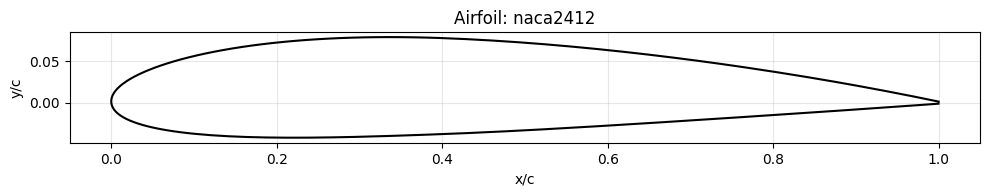

In [3]:
# Plot the airfoil
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(airfoil.coordinates[:, 0], airfoil.coordinates[:, 1], "k-", lw=1.5)
ax.set_aspect("equal")
ax.set_xlabel("x/c")
ax.set_ylabel("y/c")
ax.set_title(f"Airfoil: {airfoil.name}")
ax.grid(True, alpha=0.3)
plt.tight_layout()

## 2. Define a Wing

Wings are built from cross-sections (`WingXSec`), each with a position, chord, twist, and airfoil.

In [4]:
# Define a tapered wing with 2 degrees of washout
main_wing = ap.Wing(
    name="main_wing",
    xsecs=[
        ap.WingXSec(
            xyz_le=[0, 0, 0],          # root leading edge at origin
            chord=0.28,                  # 28 cm root chord
            twist=2.0,                   # 2 deg nose-up at root
            airfoil=ap.Airfoil("naca2412"),
        ),
        ap.WingXSec(
            xyz_le=[0.03, 0.75, 0.04],  # tip LE: slight sweep, dihedral
            chord=0.14,                  # 14 cm tip chord (taper ratio 0.5)
            twist=0.0,                   # no twist at tip (2 deg washout)
            airfoil=ap.Airfoil("naca2412"),
        ),
    ],
    symmetric=True,
    control_surfaces=[
        ap.ControlSurface(
            name="aileron",
            span_start=0.6,
            span_end=0.95,
            chord_fraction=0.25,
        ),
    ],
)

print(f"Span:          {main_wing.span():.3f} m")
print(f"Area:          {main_wing.area():.4f} m^2")
print(f"Aspect Ratio:  {main_wing.aspect_ratio():.2f}")
print(f"MAC:           {main_wing.mean_aerodynamic_chord():.4f} m")
print(f"Taper Ratio:   {main_wing.taper_ratio():.2f}")
print(f"LE Sweep:      {main_wing.sweep_le():.1f} deg")
print(f"Dihedral:      {main_wing.dihedral():.1f} deg")
print(f"AC:            {main_wing.aerodynamic_center()}")

Span:          1.500 m
Area:          0.3150 m^2
Aspect Ratio:  7.14
MAC:           0.2333 m
Taper Ratio:   0.50
LE Sweep:      2.3 deg
Dihedral:      3.1 deg
AC:            [0.06833333 0.25       0.01333333]


## 3. Define a Fuselage

Fuselages are built from cross-sections (`FuselageXSec`) at axial stations from nose to tail.

In [5]:
# Define a simple fuselage with circular cross-sections
fuselage = ap.Fuselage(
    name="main_fuselage",
    xsecs=[
        ap.FuselageXSec(x=0.00, radius=0.01),   # nose tip
        ap.FuselageXSec(x=0.10, radius=0.04),   # nose cone
        ap.FuselageXSec(x=0.25, radius=0.05),   # max cross-section
        ap.FuselageXSec(x=0.70, radius=0.05),   # constant section
        ap.FuselageXSec(x=0.90, radius=0.03),   # tail taper
        ap.FuselageXSec(x=1.00, radius=0.01),   # tail tip
    ],
)

print(f"Length:         {fuselage.length():.2f} m")
print(f"Volume:         {fuselage.volume() * 1e6:.0f} cm^3")
print(f"Wetted area:    {fuselage.wetted_area():.4f} m^2")
print(f"Max X-sec area: {fuselage.max_cross_section_area() * 1e4:.2f} cm^2")
print(f"Fineness ratio: {fuselage.fineness_ratio():.1f}")

Length:         1.00 m
Volume:         5993 cm^3
Wetted area:    0.2623 m^2
Max X-sec area: 78.54 cm^2
Fineness ratio: 10.0


## 4. Define a Flight Condition

A `FlightCondition` captures the aerodynamic state: airspeed, altitude, angle of attack, and control surface deflections. It also computes atmosphere properties via the ISA model.

In [6]:
# Cruise condition at 150 m altitude
cruise = ap.FlightCondition(
    velocity=15.0,       # 15 m/s airspeed
    altitude=150.0,      # 150 m above sea level
    alpha=3.0,           # 3 degrees angle of attack
    deflections={"elevator": -2.0, "aileron": 0.0},
)

T, P, rho, mu = cruise.atmosphere()
print(f"Airspeed:        {cruise.velocity:.1f} m/s")
print(f"Altitude:        {cruise.altitude:.0f} m")
print(f"Alpha:           {cruise.alpha:.1f} deg")
print(f"Mach:            {cruise.mach():.4f}")
print(f"Dynamic press.:  {cruise.dynamic_pressure():.1f} Pa")
print(f"Reynolds (MAC):  {cruise.reynolds_number(main_wing.mean_aerodynamic_chord()):.0f}")
print(f"Air density:     {rho:.4f} kg/m^3")
print(f"Temperature:     {T - 273.15:.1f} °C")

Airspeed:        15.0 m/s
Altitude:        150 m
Alpha:           3.0 deg
Mach:            0.0442
Dynamic press.:  135.8 Pa
Reynolds (MAC):  236806
Air density:     1.2074 kg/m^3
Temperature:     14.0 °C


## 5. Assemble a Complete Aircraft

The `Aircraft` is the top-level container that holds all components. Tail surfaces use the same `Wing` class as the main wing.

In [7]:
# Horizontal tail
h_tail = ap.Wing(
    name="h_tail",
    xsecs=[
        ap.WingXSec(
            xyz_le=[0.72, 0, 0.05],
            chord=0.12,
            twist=0.0,
            airfoil=ap.Airfoil("naca0010"),
        ),
        ap.WingXSec(
            xyz_le=[0.74, 0.25, 0.05],
            chord=0.08,
            twist=0.0,
            airfoil=ap.Airfoil("naca0010"),
        ),
    ],
    symmetric=True,
    control_surfaces=[
        ap.ControlSurface(name="elevator", span_start=0.1, span_end=0.9, chord_fraction=0.35),
    ],
)

# Vertical tail
v_tail = ap.Wing(
    name="v_tail",
    xsecs=[
        ap.WingXSec(
            xyz_le=[0.70, 0, 0.0],
            chord=0.15,
            twist=0.0,
            airfoil=ap.Airfoil("naca0008"),
        ),
        ap.WingXSec(
            xyz_le=[0.75, 0, 0.15],
            chord=0.08,
            twist=0.0,
            airfoil=ap.Airfoil("naca0008"),
        ),
    ],
    symmetric=False,
    control_surfaces=[
        ap.ControlSurface(name="rudder", span_start=0.2, span_end=0.9, chord_fraction=0.35),
    ],
)

# Assemble the aircraft
aircraft = ap.Aircraft(
    name="CoreFly-1",
    wings=[main_wing, h_tail, v_tail],
    fuselages=[fuselage],
)

print(f"Aircraft:        {aircraft.name}")
print(f"Wings:           {[w.name for w in aircraft.wings]}")
print(f"Ref. area:       {aircraft.reference_area():.4f} m^2")
print(f"Ref. span:       {aircraft.reference_span():.3f} m")
print(f"Ref. chord (MAC):{aircraft.reference_chord():.4f} m")

Aircraft:        CoreFly-1
Wings:           ['main_wing', 'h_tail', 'v_tail']
Ref. area:       0.3150 m^2
Ref. span:       1.500 m
Ref. chord (MAC):0.2333 m
